<a href="https://colab.research.google.com/github/imaisnaini/data-science-2026/blob/main/Pertemuan4_Fatimah_Isnaini_Shabrina__250401020073.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📚 **Practice 4 : Statistika Dasar & Analisis Data**
---
##👩‍🎓 **Student Information**
- **Name**: Fatimah Isnaini Shabrina
- **NIM**: 250401020073
- **University**: UNSIA - Universitas Siber Asia
- **Class**: IF401 Data Science
---
### Step 1 : Load & Inspect Dataset

In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

df = sns.load_dataset('iris')
print('Shape:', df.shape)
print(df.dtypes)
print(df.head())
print(df.describe().round(3))

Shape: (150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
       sepal_length  sepal_width  petal_length  petal_width
count       150.000      150.000       150.000      150.000
mean          5.843        3.057         3.758        1.199
std           0.828        0.436         1.765        0.762
min           4.300        2.000         1.000        0.100
25%           5.100        2.800         1.600        0.300
50%           5.800        3.000         4.350        1.300
75%           6.400        3.300         5.100



> **Gambaran Data**: Kita menganalisis dataset bunga Iris, yang berisi 150 data bunga dengan 5 informasi: panjang kelopak (sepal length), lebar kelopak (sepal width), panjang mahkota (petal length), lebar mahkota (petal width) – semuanya dalam angka – serta jenis spesies bunga tersebut.



### Step 2 : Statistik Deskriptif

In [ ]:
for col_name in df.select_dtypes(include='number').columns:
  col = df[col_name]
  print(f'\n=== {col_name} ===')
  print(f' Mean : {col.mean():.3f}')
  print(f' Median : {col.median():.3f}')
  print(f' Std Dev : {col.std():.3f}')
  print(f' Skewness : {col.skew():.3f}')
  print(f' Kurtosis : {col.kurt():.3f}')


=== sepal_length ===
 Mean : 5.843
 Median : 5.800
 Std Dev : 0.828
 Skewness : 0.315
 Kurtosis : -0.552

=== sepal_width ===
 Mean : 3.057
 Median : 3.000
 Std Dev : 0.436
 Skewness : 0.319
 Kurtosis : 0.228

=== petal_length ===
 Mean : 3.758
 Median : 4.350
 Std Dev : 1.765
 Skewness : -0.275
 Kurtosis : -1.402

=== petal_width ===
 Mean : 1.199
 Median : 1.300
 Std Dev : 0.762
 Skewness : -0.103
 Kurtosis : -1.341




> **Panjang & Lebar Kelopak**: Rata-rata dan nilai tengah (median) untuk panjang dan lebar kelopak cukup berdekatan, menunjukkan distribusinya cenderung simetris atau normal.

> **Panjang & Lebar Mahkota**: Ada sedikit perbedaan antara rata-rata dan nilai tengah untuk panjang dan lebar mahkota, dan distribusinya cenderung sedikit miring ke kiri.






### Step 3 : Analisis Distribusi (Histogram + KDE)

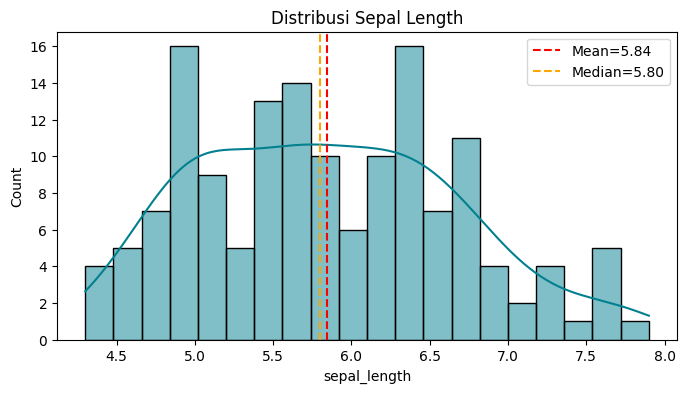

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(
    df['sepal_length'],
    kde=True,
    color='#028090',
    bins=20,
    ax=ax)

ax.axvline(
    df['sepal_length'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean={df['sepal_length'].mean():.2f}")

ax.axvline(
    df['sepal_length'].median(),
    color='orange',
    linestyle='--',
    label=f"Median={df['sepal_length'].median():.2f}")

ax.set_title('Distribusi Sepal Length'); ax.legend(); plt.show()



> **Distribusi (Panjang Kelopak)**: Histogram panjang kelopak menunjukkan bahwa data terdistribusi cukup merata di sekitar nilai tengahnya, dengan sebagian besar data terkumpul di tengah.



### Step 4 : Box Plot per Spesies

/tmp/ipykernel_699/2572918780.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_699/2572918780.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


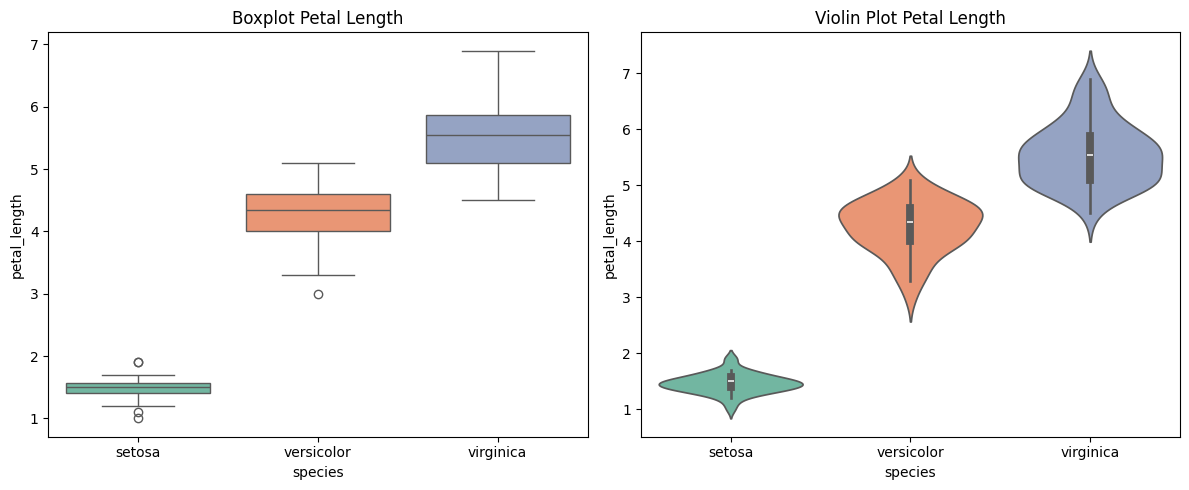

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(
    data=df,
    x='species',
    y='petal_length',
    palette='Set2',
    ax=axes[0])
axes[0].set_title('Boxplot Petal Length')

sns.violinplot(
    data=df,
    x='species',
    y='petal_length',
    palette='Set2',
    inner='box',
    ax=axes[1])
axes[1].set_title('Violin Plot Petal Length')

plt.tight_layout(); plt.show()



> **Perbandingan Antar Spesies (Panjang Mahkota)**: Plot kotak dan biola menunjukkan bahwa panjang mahkota adalah fitur yang sangat baik untuk membedakan spesies Iris:
*   Setosa: Memiliki mahkota yang jauh lebih pendek.
*   Versicolor: Memiliki panjang mahkota menengah.
*   Virginica: Memiliki mahkota terpanjang.

### Step 5 : Matriks Korelasi Pearson

In [ ]:

import numpy as np

corr = df.drop('species', axis=1).corr(method='pearson')
print(corr.round(3))

mask = np.triu(np.ones(corr.shape, dtype=bool))
corr_masked = corr.where(~mask)
max_pair = corr_masked.stack().idxmax()
print(f'Korelasi tertinggi: {max_pair} = {corr.loc[max_pair]:.3f}')

              sepal_length  sepal_width  petal_length  petal_width
sepal_length         1.000       -0.118         0.872        0.818
sepal_width         -0.118        1.000        -0.428       -0.366
petal_length         0.872       -0.428         1.000        0.963
petal_width          0.818       -0.366         0.963        1.000
Korelasi tertinggi: ('petal_width', 'petal_length') = 0.963




> **Korelasi Terkuat**: Ada korelasi yang sangat kuat antara panjang mahkota dan lebar mahkota (0.963). Ini berarti jika mahkota panjang, kemungkinan besar lebarnya juga besar.

> **Korelasi Kuat Lainnya**: Panjang kelopak juga sangat berkorelasi dengan panjang dan lebar mahkota.

> **Korelasi Lemah**: Lebar kelopak memiliki korelasi yang lemah atau negatif dengan fitur lainnya.



### Step 6 : Scatter Plot & Heatmap

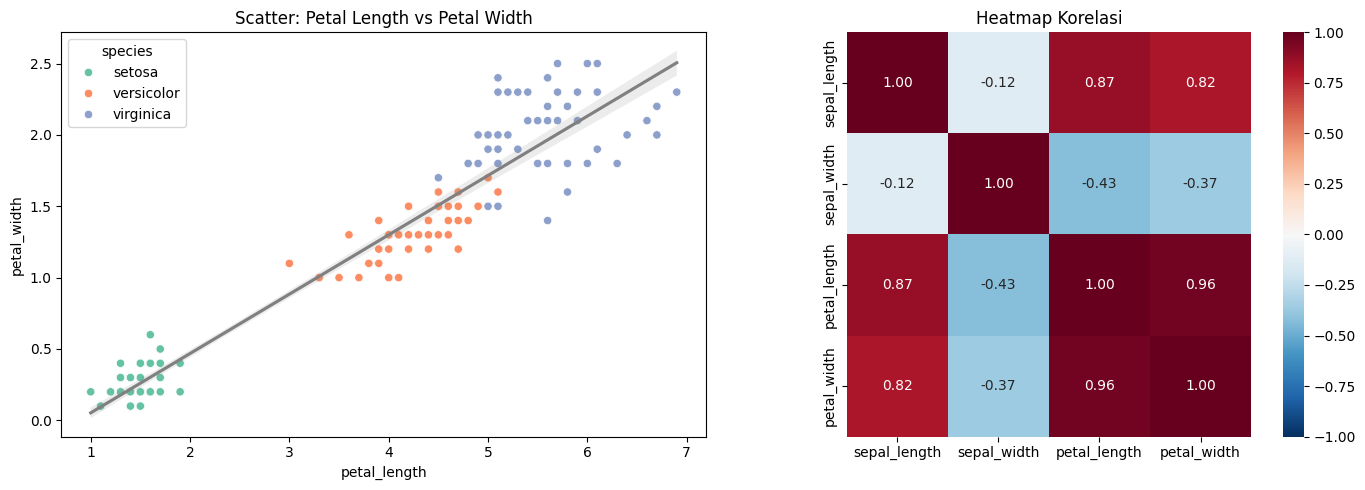

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species',
    palette='Set2',
    ax=axes[0])

sns.regplot(
    data=df,
    x='petal_length',
    y='petal_width',
    scatter=False,
    color='gray',
    ax=axes[0])

axes[0].set_title('Scatter: Petal Length vs Petal Width')

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    vmin=-1,
    vmax=1,
    square=True,
    ax=axes[1])

axes[1].set_title('Heatmap Korelasi')
plt.tight_layout(); plt.show()



> **Visualisasi Korelasi**: Scatter plot dan heatmap secara visual mengkonfirmasi temuan korelasi ini. Kita bisa melihat dengan jelas bagaimana panjang dan lebar mahkota secara efektif memisahkan tiga spesies Iris yang berbeda.



## 📝 Notes :


*   Data Iris terdiri dari 150 entri dengan fitur panjang/lebar kelopak dan mahkota, serta jenis spesies.
*   Panjang dan lebar kelopak cenderung berdistribusi normal, sedangkan panjang dan lebar mahkota sedikit miring ke kiri.
*   Panjang mahkota adalah fitur yang sangat efektif untuk membedakan antar spesies Iris.
*   Terdapat korelasi positif yang sangat kuat antara panjang dan lebar mahkota, serta korelasi yang kuat antara panjang kelopak dengan dimensi mahkota.
*   Visualisasi menunjukkan bahwa fitur panjang dan lebar mahkota sangat baik dalam mengelompokkan spesies Iris yang berbeda secara visual.

